In [1]:
import os

import numpy as np
import pandas as pd

from hyperopt import hp

from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier

from sklift.datasets import fetch_hillstrom
from sklift.metrics import qini_auc_score, uplift_at_k

from upninja.dml.uplift_forest_dml import UpliftRandomForestDML
from upninja.dml.uplift_tree_dml import UpliftTreeRegressorDML
from upninja.tune.selection import UpliftTune
from upninja.utils import uplift_plot

import matplotlib.pyplot as plt
import seaborn as sns

/Users/romanseleznyov/Documents/UpliftNinja/uplift-env/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/romanseleznyov/Documents/UpliftNinja/uplift-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


In [2]:
SEED = 42

# ✅ Fetch & Preproc

In [3]:
data = fetch_hillstrom(target_col='visit')
df = data.data
X, y, w = df, data.target, data.treatment

# Hillstrom: treatment — 'Mens E-Mail', 'Womens E-Mail' -> объединим в бинарный treatment
w = (w != 'No E-Mail').astype(int)  # 1 — получили email, 0 — нет

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=SEED
)

num_cols = X_train.select_dtypes(exclude='object').columns
X_train = X_train[num_cols]
X_test = X_test[num_cols]

# ✅ Build UpNinja model

In [4]:
%%time

space = {
    'min_samples': hp.uniformint('min_samples', 20, 500),
    'max_depth': hp.uniformint('max_depth', 3, 20),
    'random_state': SEED
}

dml_tune = UpliftTune(
    uplift_model_class=UpliftTreeRegressorDML,
    data=X_train,
    target=y_train,
    treatment=w_train,
    space=space,
    verbose=True,
    max_evals=15
)

dml_tuned = dml_tune.tune()['best_params']

100%|███████| 15/15 [00:02<00:00,  6.31trial/s, best loss: -0.07361440689763528]
Optimization completed. Best score: 0.0736
Best parameters: {'max_depth': 5, 'min_samples': 261, 'random_state': 42}
CPU times: user 2.35 s, sys: 34.5 ms, total: 2.39 s
Wall time: 2.38 s


In [5]:
%%time
rf_un = UpliftRandomForestDML(
    **dml_tuned
)

rf_un.fit(X_train, y_train, w_train)
uplift_un = rf_un.predict(X_test)

un_score = uplift_at_k(y_true=y_test, uplift=uplift_un, treatment=w_test, strategy='by_group', k=0.3)
un_score_q = qini_auc_score(y_true=y_test, uplift=uplift_un, treatment=w_test)

CPU times: user 1.12 s, sys: 7.06 ms, total: 1.12 s
Wall time: 1.12 s


# ✅ Score

In [6]:
print(f'Uplift score at 30%: {un_score}')
print(f'Qini score: {un_score_q}')

Uplift score at 30%: 0.09246292155341579
Qini score: 0.036765608399815485


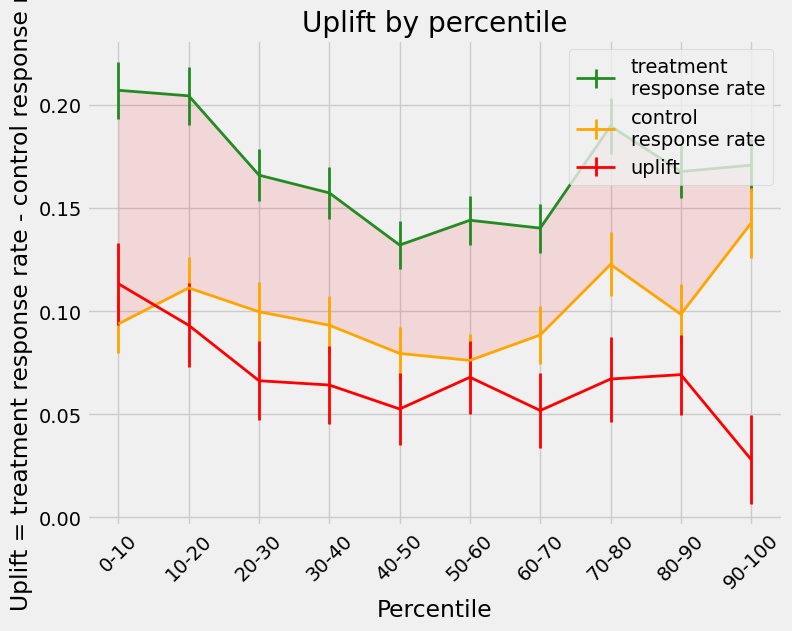

In [7]:
uplift_plot.plot_uplift_by_percentile(y_test,
                                      uplift_un,
                                      w_test,
                                      strategy = 'overall',
                                      kind = 'line')

plt.show()

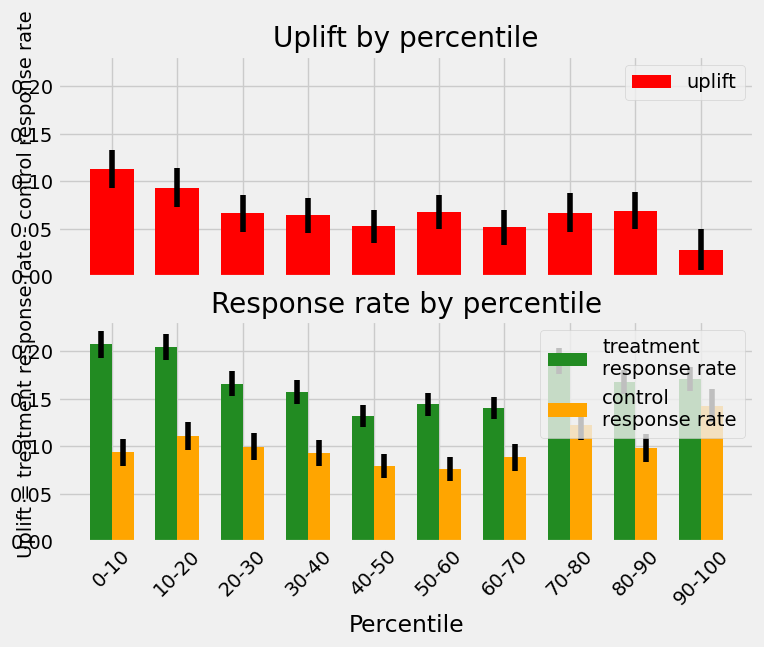

In [8]:
uplift_plot.plot_uplift_by_percentile(y_test,
                                      uplift_un,
                                      w_test,
                                      strategy = 'overall',
                                      kind = 'bar')

plt.show()

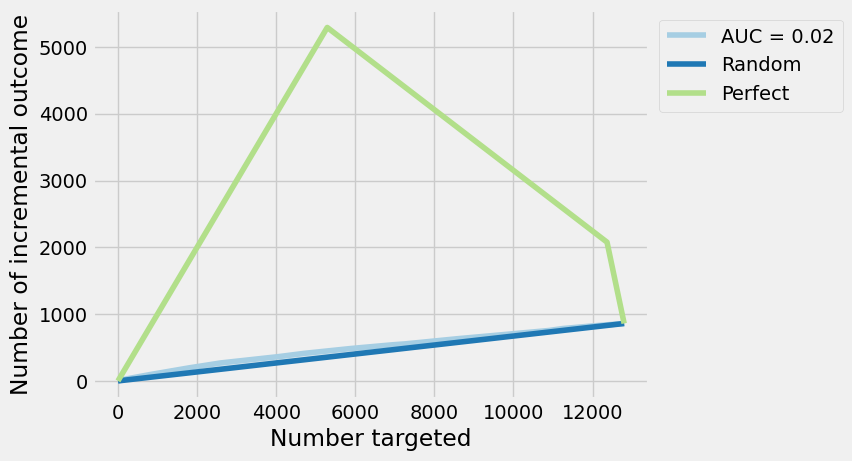

In [9]:
uplift_plot.plot_uplift_curve(y_test,
                              uplift_un,
                              w_test,
                              perfect = True)

plt.show()

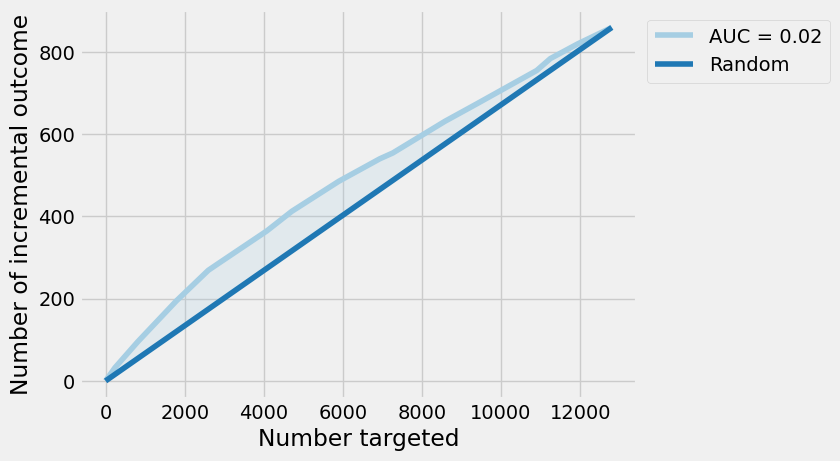

In [10]:
uplift_plot.plot_uplift_curve(y_test,
                              uplift_un,
                              w_test,
                              perfect = False)

plt.show()

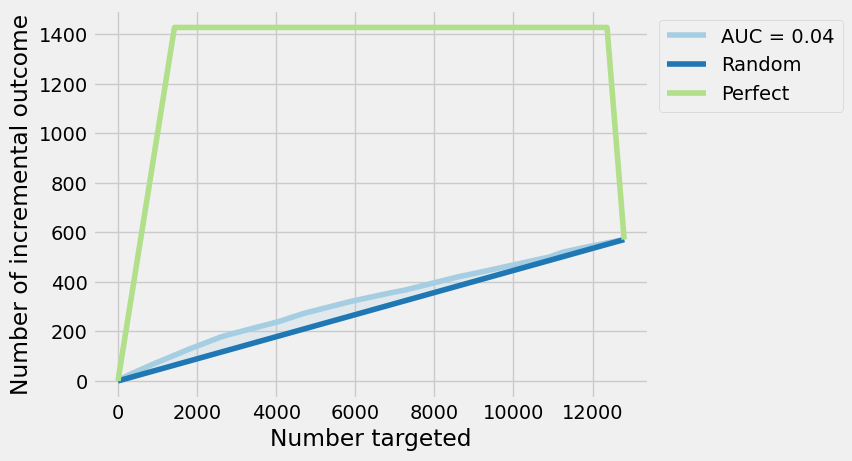

In [11]:
uplift_plot.plot_qini_curve(y_test,
                            uplift_un,
                            w_test,
                            perfect = True)

plt.show()

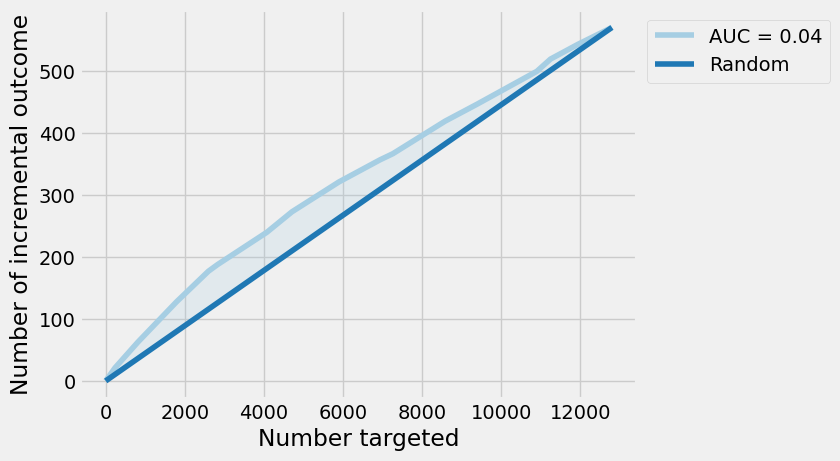

In [12]:
uplift_plot.plot_qini_curve(y_test,
                            uplift_un,
                            w_test,
                            perfect = False)

plt.show()